In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (16, 5)
plt.rcParams['figure.dpi'] = 100

DATA_DIR = 'g4/'

cart = pd.read_csv(f'{DATA_DIR}metrics/cart-service.csv', parse_dates=['timestamp'])
order = pd.read_csv(f'{DATA_DIR}metrics/order-service.csv', parse_dates=['timestamp'])
payment = pd.read_csv(f'{DATA_DIR}metrics/payment-service.csv', parse_dates=['timestamp'])
gateway = pd.read_csv(f'{DATA_DIR}metrics/api-gateway.csv', parse_dates=['timestamp'])
product = pd.read_csv(f'{DATA_DIR}metrics/product-service.csv', parse_dates=['timestamp'])

# Define feature columns for cart-service (excluding timestamp & memory_limit which is constant)
cart_features = ['memory_usage_bytes', 'cpu_usage_percent', 'http_requests_per_sec',
                 'http_p99_latency_ms', 'http_5xx_rate', 'jvm_gc_pause_ms_avg',
                 'container_restart_count']

print(f"Cart-service: {cart.shape[0]} data points, {len(cart_features)} features")
print(f"Time range: {cart['timestamp'].min()} → {cart['timestamp'].max()}")


Cart-service: 2820 data points, 7 features
Time range: 2026-06-01 00:00:00+00:00 → 2026-06-01 23:59:30+00:00


Z-Score Method: 26 anomalous data points out of 2820 (0.9%)


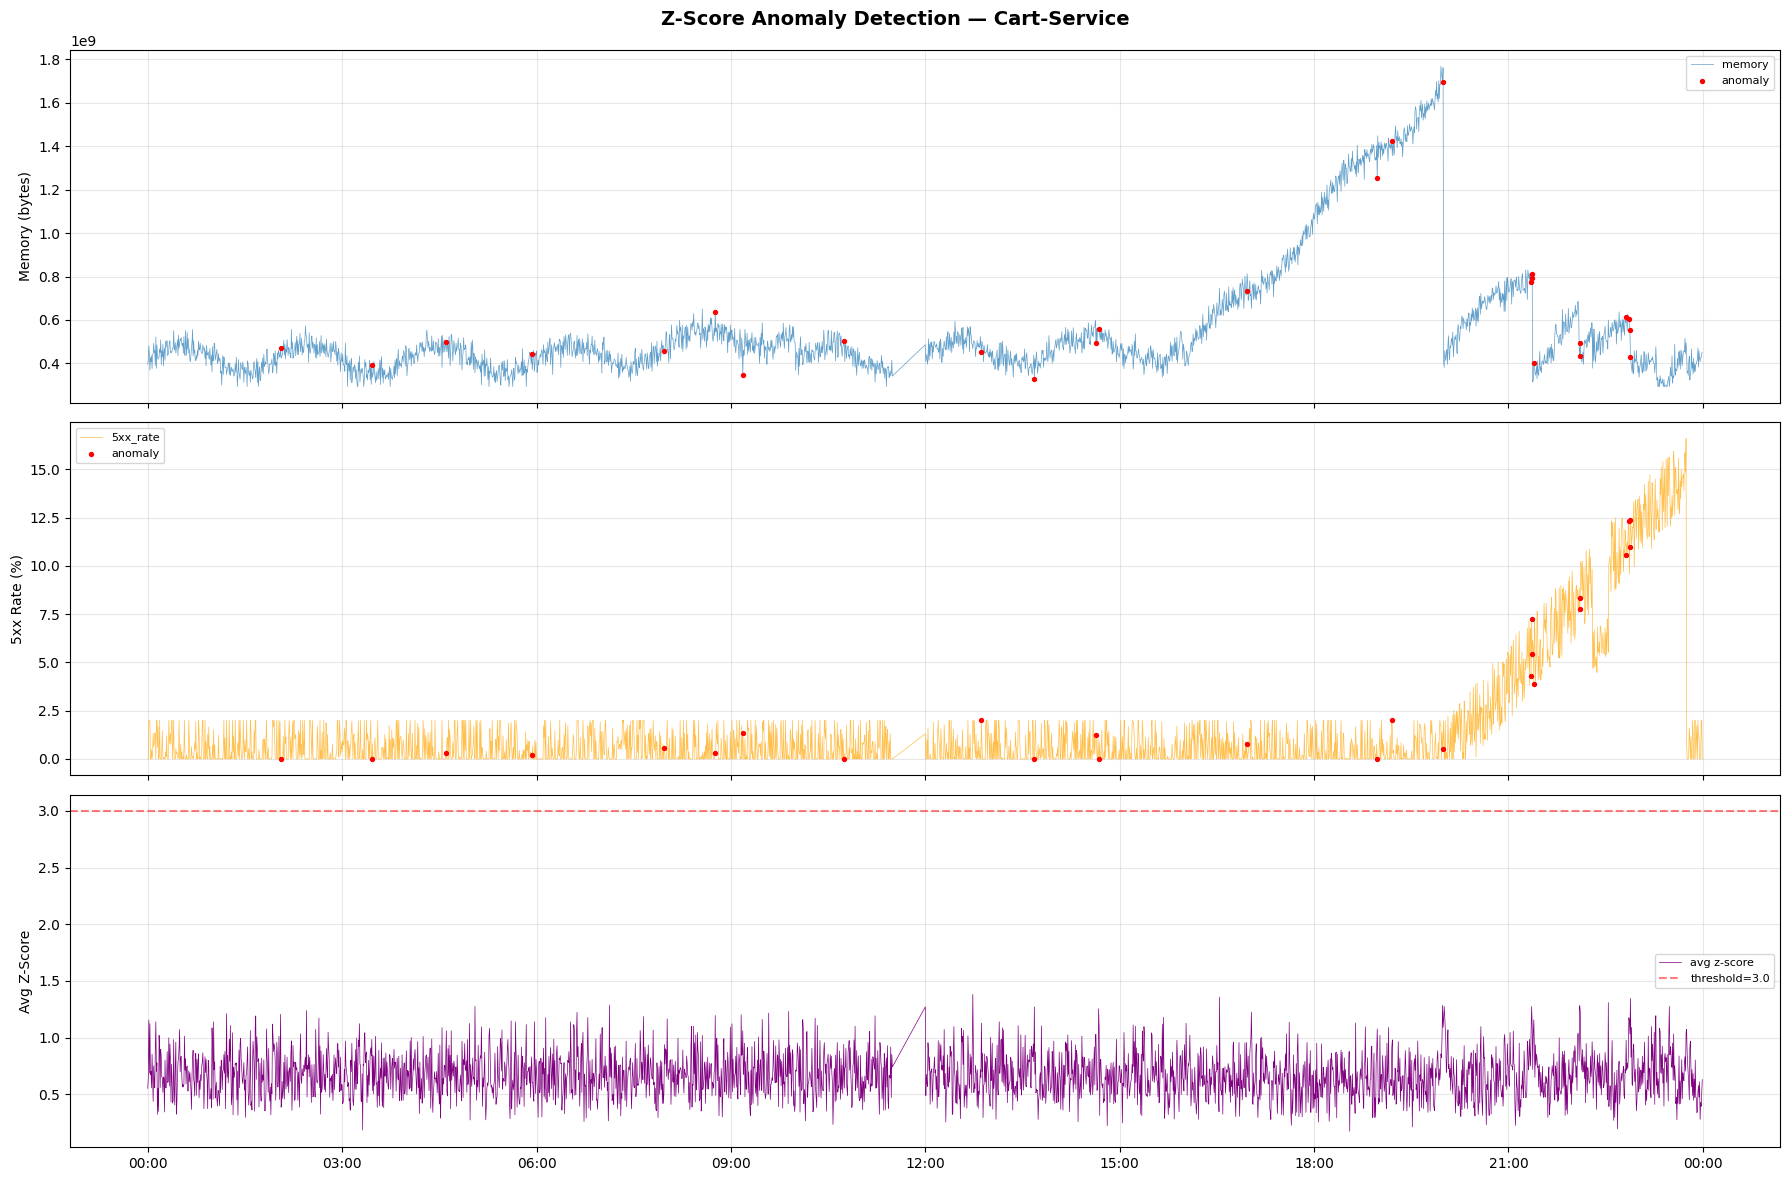

In [2]:
def zscore_anomalies(df, columns, threshold=3.0, window=60):
    """
    Detect anomalies using rolling Z-score.
    window: number of periods for rolling mean/std (60 periods = 30 min at 30s interval)
    """
    results = pd.DataFrame(index=df.index)
    results['timestamp'] = df['timestamp']
    results['is_anomaly'] = False
    results['anomaly_score'] = 0.0

    for col in columns:
        rolling_mean = df[col].rolling(window=window, center=True, min_periods=10).mean()
        rolling_std = df[col].rolling(window=window, center=True, min_periods=10).std()
        z_scores = ((df[col] - rolling_mean) / rolling_std).abs()
        z_scores = z_scores.fillna(0)
        results[f'{col}_zscore'] = z_scores
        results['anomaly_score'] += z_scores
        results['is_anomaly'] |= (z_scores > threshold)

    results['anomaly_score'] /= len(columns)
    return results

# Apply to cart-service
cart_zscore = zscore_anomalies(cart, cart_features, threshold=3.0, window=60)

n_anomalies = cart_zscore['is_anomaly'].sum()
print(f"Z-Score Method: {n_anomalies} anomalous data points out of {len(cart_zscore)} ({100*n_anomalies/len(cart_zscore):.1f}%)")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle('Z-Score Anomaly Detection — Cart-Service', fontsize=14, fontweight='bold')

anomaly_mask = cart_zscore['is_anomaly']

ax = axes[0]
ax.plot(cart['timestamp'], cart['memory_usage_bytes'], linewidth=0.5, alpha=0.7, label='memory')
ax.scatter(cart.loc[anomaly_mask, 'timestamp'], cart.loc[anomaly_mask, 'memory_usage_bytes'],
           c='red', s=8, zorder=5, label='anomaly')
ax.set_ylabel('Memory (bytes)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(cart['timestamp'], cart['http_5xx_rate'], linewidth=0.5, alpha=0.7, label='5xx_rate', color='orange')
ax.scatter(cart.loc[anomaly_mask, 'timestamp'], cart.loc[anomaly_mask, 'http_5xx_rate'],
           c='red', s=8, zorder=5, label='anomaly')
ax.set_ylabel('5xx Rate (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(cart_zscore['timestamp'], cart_zscore['anomaly_score'], linewidth=0.5, color='purple', label='avg z-score')
ax.axhline(y=3.0, color='red', linestyle='--', alpha=0.5, label='threshold=3.0')
ax.set_ylabel('Avg Z-Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


Isolation Forest: 141 anomalies out of 2820 (5.0%)


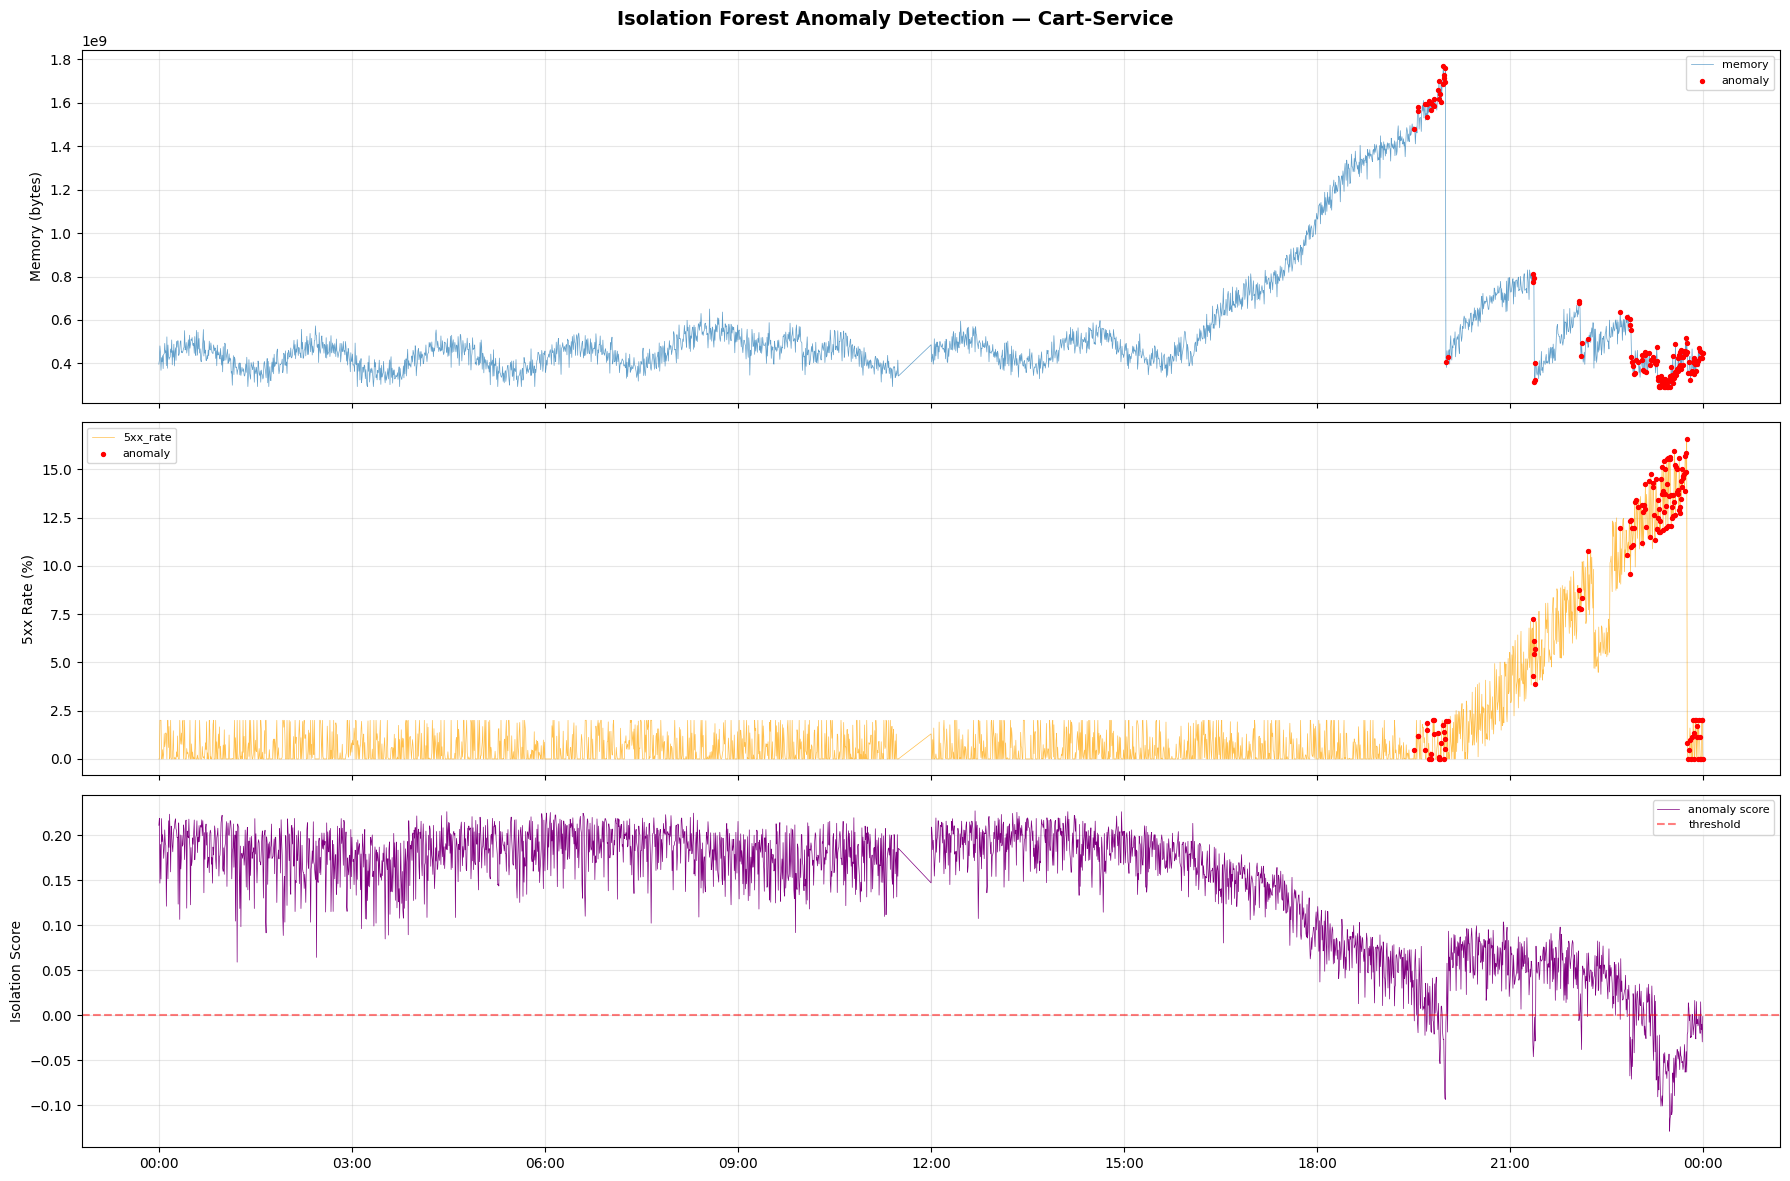

In [3]:
# Prepare features
scaler = StandardScaler()
X_cart = scaler.fit_transform(cart[cart_features].fillna(0))

# Train Isolation Forest
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  # expect ~5% anomalies
    random_state=42,
    n_jobs=-1
)
cart['iso_label'] = iso_forest.fit_predict(X_cart)
cart['iso_score'] = iso_forest.decision_function(X_cart)

n_iso_anomalies = (cart['iso_label'] == -1).sum()
print(f"Isolation Forest: {n_iso_anomalies} anomalies out of {len(cart)} ({100*n_iso_anomalies/len(cart):.1f}%)")

# Plot
fig, axes = plt.subplots(3, 1, figsize=(18, 12), sharex=True)
fig.suptitle('Isolation Forest Anomaly Detection — Cart-Service', fontsize=14, fontweight='bold')

iso_anomaly_mask = cart['iso_label'] == -1

ax = axes[0]
ax.plot(cart['timestamp'], cart['memory_usage_bytes'], linewidth=0.5, alpha=0.7, label='memory')
ax.scatter(cart.loc[iso_anomaly_mask, 'timestamp'], cart.loc[iso_anomaly_mask, 'memory_usage_bytes'],
           c='red', s=8, zorder=5, label='anomaly')
ax.set_ylabel('Memory (bytes)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(cart['timestamp'], cart['http_5xx_rate'], linewidth=0.5, alpha=0.7, label='5xx_rate', color='orange')
ax.scatter(cart.loc[iso_anomaly_mask, 'timestamp'], cart.loc[iso_anomaly_mask, 'http_5xx_rate'],
           c='red', s=8, zorder=5, label='anomaly')
ax.set_ylabel('5xx Rate (%)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.plot(cart['timestamp'], cart['iso_score'], linewidth=0.5, color='purple', label='anomaly score')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='threshold')
ax.set_ylabel('Isolation Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()


=== Method Comparison ===
Z-Score only:         15
Isolation Forest only: 130
Both agree (anomaly):  11
Either method:         156


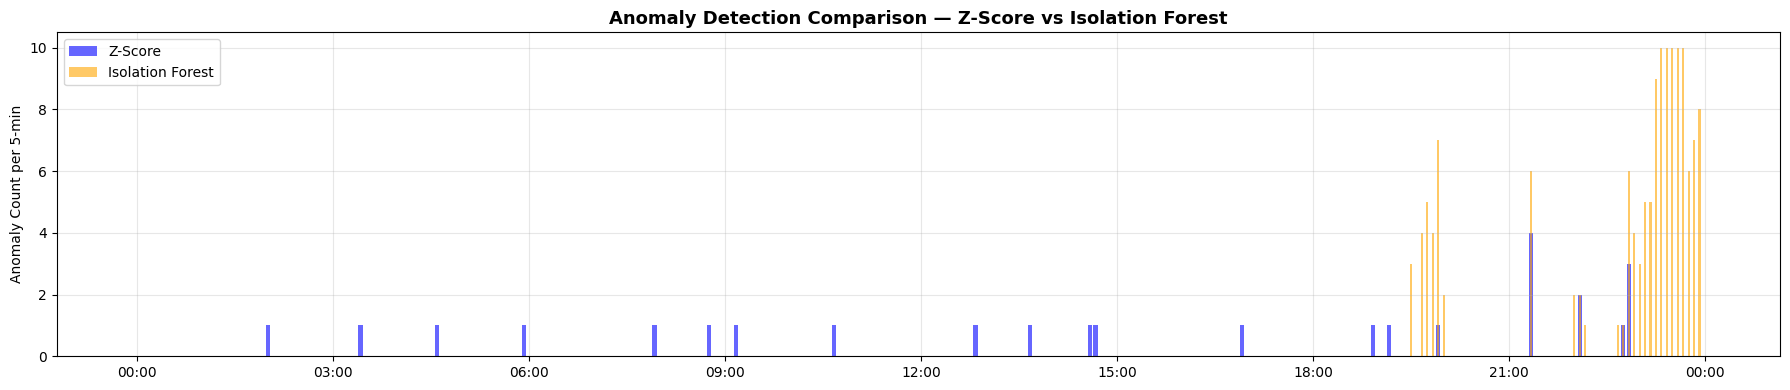

In [4]:
# Compare the two methods
cart_compare = pd.DataFrame({
    'timestamp': cart['timestamp'],
    'zscore_anomaly': cart_zscore['is_anomaly'].astype(int),
    'isoforest_anomaly': (cart['iso_label'] == -1).astype(int),
})
cart_compare['both'] = cart_compare['zscore_anomaly'] & cart_compare['isoforest_anomaly']
cart_compare['either'] = cart_compare['zscore_anomaly'] | cart_compare['isoforest_anomaly']

print("=== Method Comparison ===")
print(f"Z-Score only:         {(cart_compare['zscore_anomaly'] & ~cart_compare['isoforest_anomaly']).sum()}")
print(f"Isolation Forest only: {(cart_compare['isoforest_anomaly'] & ~cart_compare['zscore_anomaly']).sum()}")
print(f"Both agree (anomaly):  {cart_compare['both'].sum()}")
print(f"Either method:         {cart_compare['either'].sum()}")

# Timeline comparison
fig, ax = plt.subplots(figsize=(18, 4))
ax.set_title('Anomaly Detection Comparison — Z-Score vs Isolation Forest', fontsize=13, fontweight='bold')

# Resample to 5-min buckets for visibility
cart_compare.set_index('timestamp', inplace=True)
resampled = cart_compare.resample('5min').sum()

ax.bar(resampled.index, resampled['zscore_anomaly'], width=pd.Timedelta('4min'),
       alpha=0.6, label='Z-Score', color='blue')
ax.bar(resampled.index, resampled['isoforest_anomaly'], width=pd.Timedelta('2min'),
       alpha=0.6, label='Isolation Forest', color='orange')
ax.set_ylabel('Anomaly Count per 5-min')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()


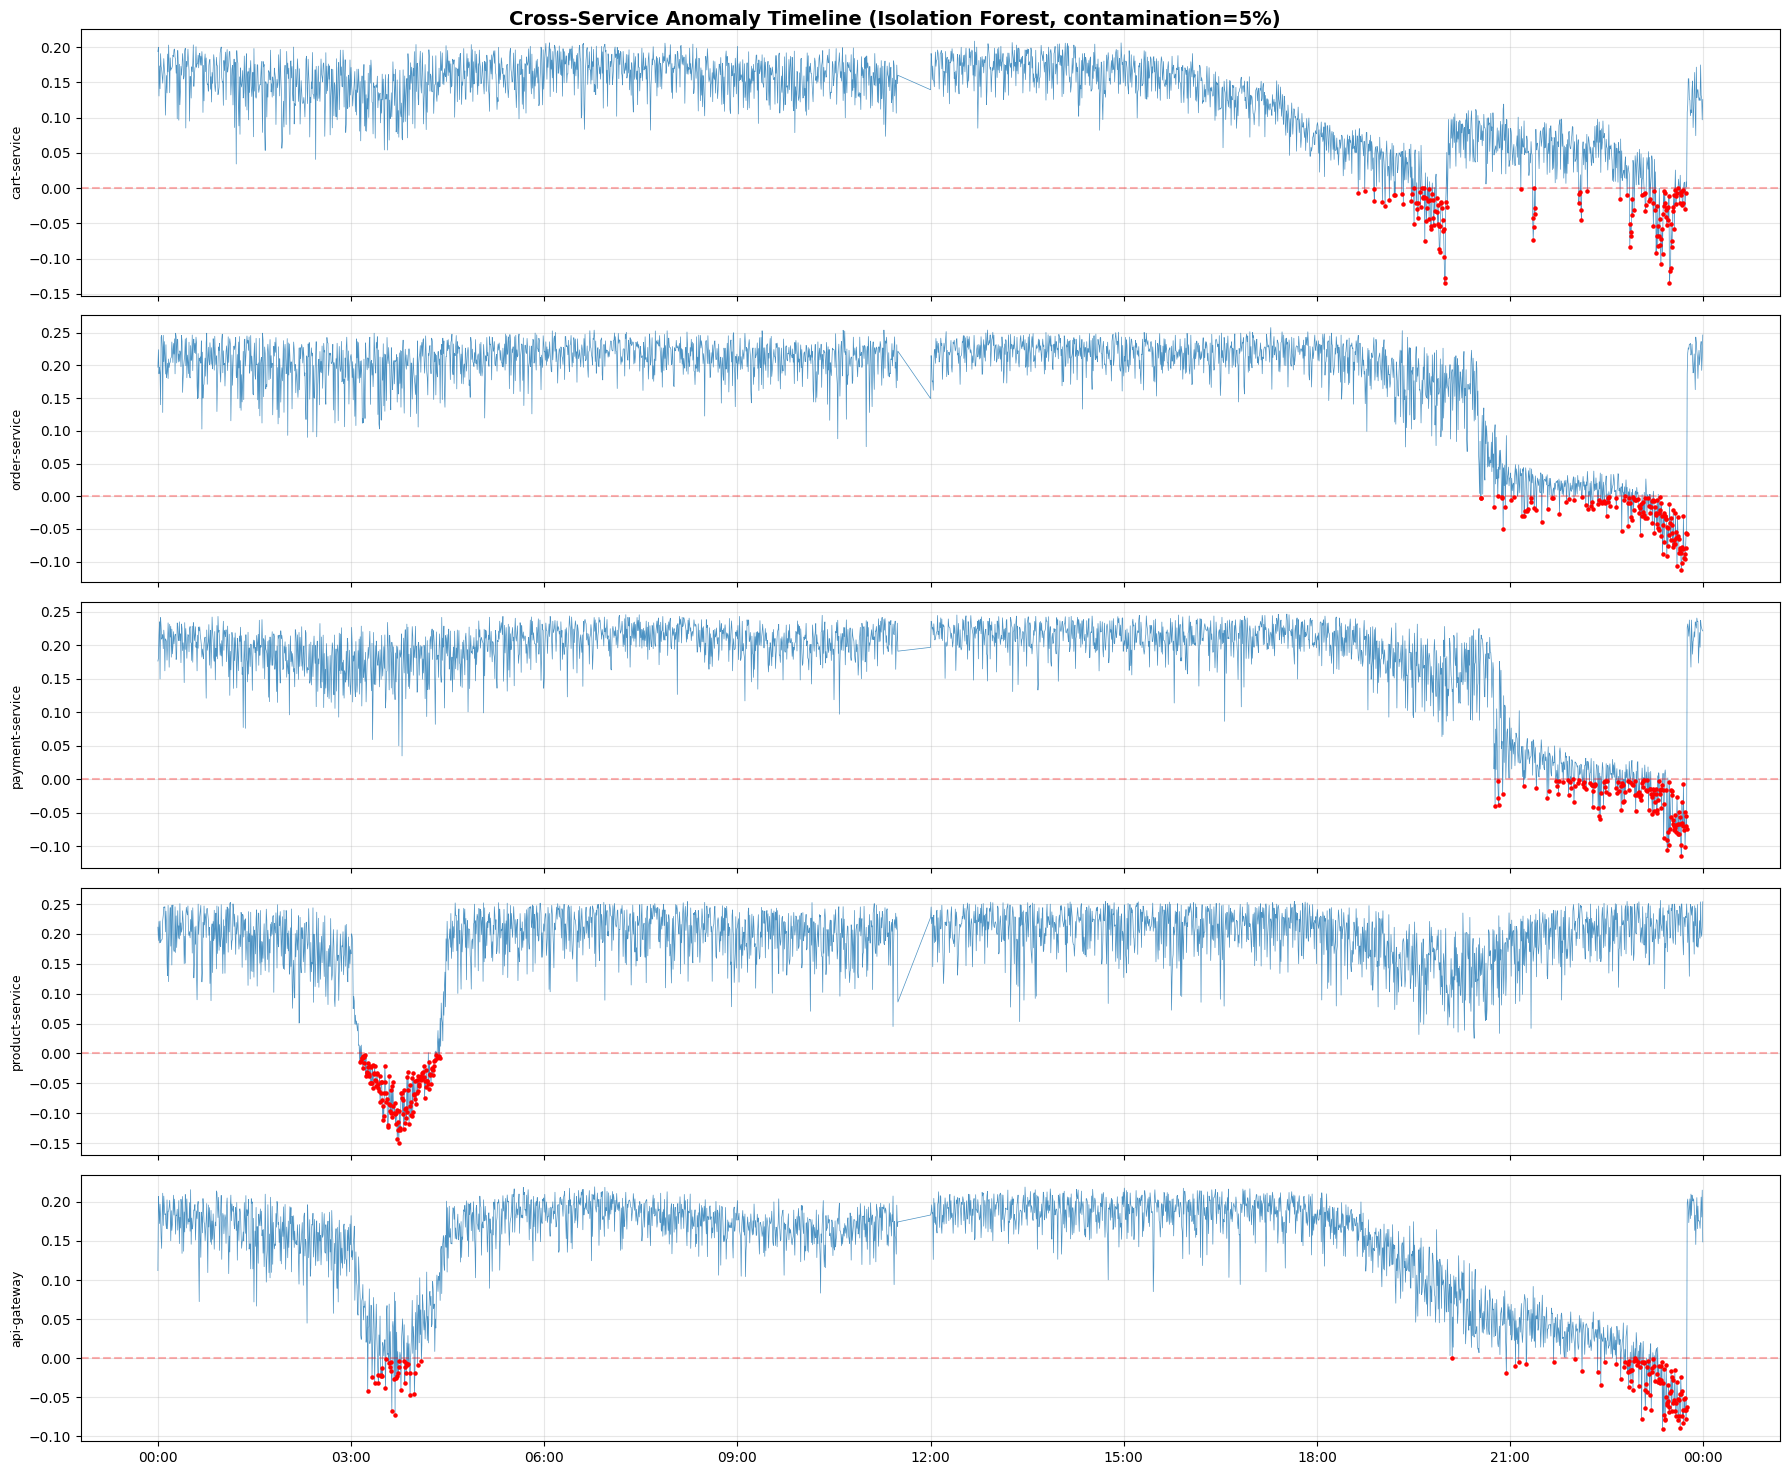

In [5]:
# Apply Isolation Forest to all services
services = {
    'cart-service': (cart, ['memory_usage_bytes', 'cpu_usage_percent', 'http_requests_per_sec',
                           'http_p99_latency_ms', 'http_5xx_rate', 'jvm_gc_pause_ms_avg']),
    'order-service': (order, ['http_requests_per_sec', 'http_p99_latency_ms',
                              'http_5xx_rate', 'upstream_timeout_rate']),
    'payment-service': (payment, ['http_requests_per_sec', 'http_p99_latency_ms',
                                  'http_5xx_rate', 'upstream_timeout_rate']),
    'product-service': (product, ['http_requests_per_sec', 'http_p99_latency_ms',
                                  'cpu_usage_percent', 'http_5xx_rate']),
    'api-gateway': (gateway, ['http_requests_per_sec', 'http_p99_latency_ms',
                              'http_5xx_rate', 'cart_upstream_error_rate',
                              'product_upstream_error_rate', 'active_connections']),
}

fig, axes = plt.subplots(len(services), 1, figsize=(18, 3*len(services)), sharex=True)
fig.suptitle('Cross-Service Anomaly Timeline (Isolation Forest, contamination=5%)',
             fontsize=14, fontweight='bold')

for idx, (name, (df, features)) in enumerate(services.items()):
    scaler = StandardScaler()
    X = scaler.fit_transform(df[features].fillna(0))
    iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
    labels = iso.fit_predict(X)
    scores = iso.decision_function(X)

    ax = axes[idx]
    ax.plot(df['timestamp'], scores, linewidth=0.5, alpha=0.8)
    anomaly_idx = labels == -1
    ax.scatter(df.loc[anomaly_idx, 'timestamp'], scores[anomaly_idx],
               c='red', s=5, zorder=5)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_ylabel(name, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.tight_layout()
plt.show()


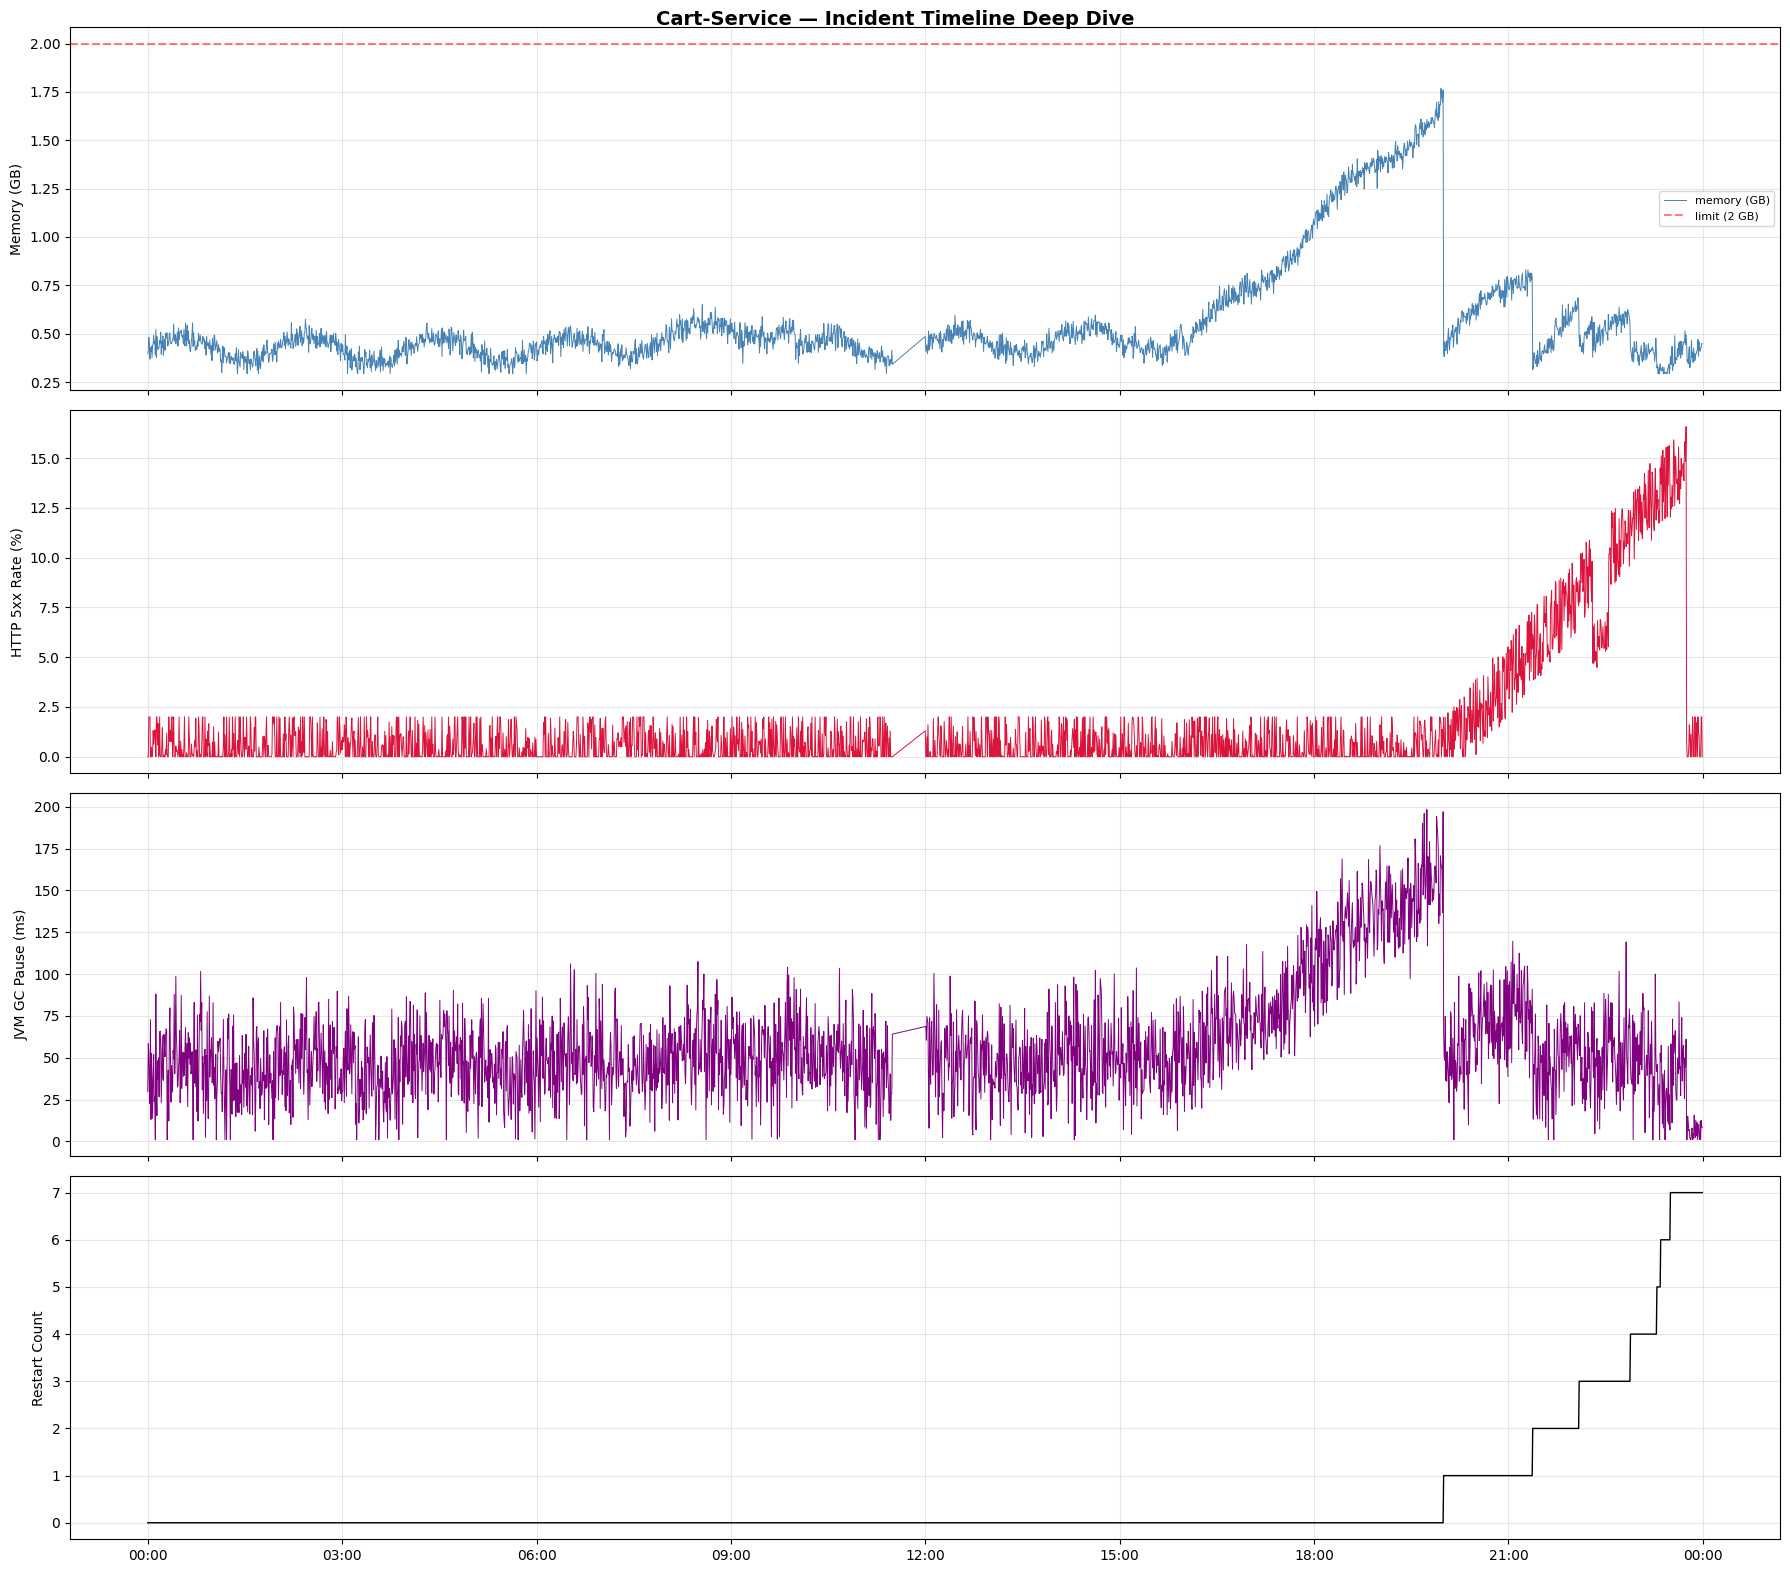

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(18, 16), sharex=True)
fig.suptitle('Cart-Service — Incident Timeline Deep Dive', fontsize=14, fontweight='bold')

# Memory with limit
ax = axes[0]
ax.plot(cart['timestamp'], cart['memory_usage_bytes'] / 1e9, linewidth=0.7, color='steelblue', label='memory (GB)')
ax.axhline(y=2.0, color='red', linestyle='--', alpha=0.5, label='limit (2 GB)')
ax.set_ylabel('Memory (GB)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# 5xx rate
ax = axes[1]
ax.plot(cart['timestamp'], cart['http_5xx_rate'], linewidth=0.7, color='crimson')
ax.set_ylabel('HTTP 5xx Rate (%)')
ax.grid(True, alpha=0.3)

# GC pause
ax = axes[2]
ax.plot(cart['timestamp'], cart['jvm_gc_pause_ms_avg'], linewidth=0.7, color='purple')
ax.set_ylabel('JVM GC Pause (ms)')
ax.grid(True, alpha=0.3)

# Container restarts
ax = axes[3]
ax.plot(cart['timestamp'], cart['container_restart_count'], linewidth=1, color='black')
ax.set_ylabel('Restart Count')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

plt.tight_layout()
plt.show()
